# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [28]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr

### Cargar Dataset

In [29]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [30]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- nivel_ingreso
- visitas_mes
- compras_mes
- gasto_publicidad_dirigida
- satisfaccion

La mayoría de estas variables presentan tipos de datos adecuados.  

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [46]:
df.isna().sum()

id_cliente                   0
edad                         0
nivel_ingreso                0
visitas_mes                  0
compras_mes                  0
gasto_publicidad_dirigida    0
satisfaccion                 0
miembro_premium              0
abandono                     0
tipo_dispositivo             0
region                       0
ingreso_anual                0
dtype: int64

# Corregir el tipo de dato
No requirio corregir algún dato


In [47]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [48]:
# Estadísticas descriptivas de variables numéricas
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,15000,15000,CL-103653,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,15000.0,NaN,NaN,NaN,38.2624,11.492378,18.0,30.0,38.0,46.0,75.0
nivel_ingreso,15000.0,NaN,NaN,NaN,30019.704782,9833.166305,8000.0,23127.0975,30023.745,36768.44,74790.84
visitas_mes,15000.0,NaN,NaN,NaN,10.029,3.158189,1.0,8.0,10.0,12.0,25.0
compras_mes,15000.0,NaN,NaN,NaN,1.206467,1.105284,0.0,0.0,1.0,2.0,8.0
gasto_publicidad_dirigida,15000.0,NaN,NaN,NaN,20.149301,10.880724,0.0,12.31,19.73,27.2925,75.51
satisfaccion,15000.0,NaN,NaN,NaN,3.603693,0.6853,1.0,3.1,3.6,4.1,5.0
miembro_premium,15000.0,NaN,NaN,NaN,0.139267,0.346236,0.0,0.0,0.0,0.0,1.0
abandono,15000.0,NaN,NaN,NaN,0.150733,0.357801,0.0,0.0,0.0,0.0,1.0
tipo_dispositivo,15000,3,móvil,9818,NaN,NaN,NaN,NaN,NaN,NaN,NaN


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad`= La edad minima es de 18 años la máxima es 75 años
- `nivel_ingreso`= El promedio y la media es muy parecida,cuenta con una ligera diferencia
- `visitas_mes`= El minimo de visitas al mes es 1 y el máximo es 25
- `compras_mes`=El promedio supera a la mediana por una diferencia de 0.2 puntos. La compra menor es 0 y la maxima es 8
- `gasto_publicidad_dirigida`=Tiene una ligera diferencia entre promedio y mediana, el promedio supera a la mediana por una diferencia de 0.41   
- `satisfaccion`=El valor promedio es de 3.6 igual que la mediana 
- `ingreso_anual`=Con un rango de 0 a 244.69, el promedio supera a la mediana por una diferencia de 6
Cada uno de estos valors numérico no cuenta con valores nulos  

#### Explorar variables binarias

In [49]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ["miembro_premium", "abandono"]

for col in columnas_binarias:
    valores_unicos = df[col].unique()
    print(f"Valores únicos en '{col}': {valores_unicos}")

# Si por alguna razón encuentras que son texto ("0" / "1") o tienen nulos, 
# asegúrate de que sean enteros:
df["miembro_premium"] = df["miembro_premium"].astype(int)
df["abandono"] = df["abandono"].astype(int)

Valores únicos en 'miembro_premium': [0 1]
Valores únicos en 'abandono': [0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Se identifico que los valores son enteros, y cumplen el requisito binario 0-1
- `abandono` — Se identifico que los valores son enteros, y cumplen el requisito binario 0-1

#### Explorar variables categóricas

In [50]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['tipo_dispositivo','region']

for col in columnas_categoricas:
    valores_unicos = df[col].nunique()
    print(f"Valores únicos en '{col}': {valores_unicos}")


Valores únicos en 'tipo_dispositivo': 3
Valores únicos en 'region': 4


In [51]:
# Explorar variables categóricas y cómo se distribuyen

for col in columnas_categoricas:
    print(col)
    print("\nFrecuencia relativa:")
    print(df[col].value_counts(normalize=True).map(lambda n: f"{n:.1%}"))
    print("")


tipo_dispositivo

Frecuencia relativa:
móvil         65.5%
escritorio    24.8%
tablet         9.7%
Name: tipo_dispositivo, dtype: object

region

Frecuencia relativa:
norte    29.3%
oeste    25.4%
sur      24.8%
este     20.5%
Name: region, dtype: object



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Se identifican tres categorías, donde el móvil predomina con un 65.5%, seguido por el escritorio (24.8%) y las tablets (9.7%)
- `region` — La distribución se divide en cuatro zonas, siendo el Norte la de mayor peso con un 29.3%, seguida por el Oeste (25.4%), Sur (24.8%) y Este (20.5%).

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

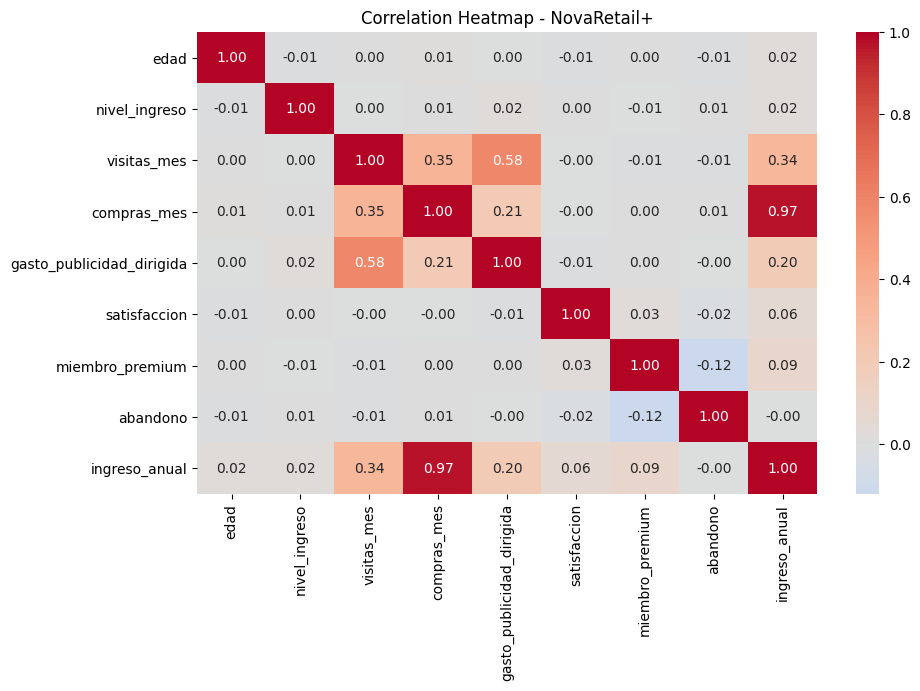

In [52]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True,fmt=".2f",cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail+")
plt.show()





✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa una diagonal principal de color rojo que representa una fuerte correlación positiva (1), eso significa una correlación consigo misma.

- Se muestra dos cuadros de tono azul ligero expresando correlación negativa (-0.12) entre la variable abandono y miembro_premium. Es una relación débil, pero negativa, lo cual es "bueno": indica que ser Premium reduce ligeramente la probabilidad de irse.

- Se muestra que las variables compas_mes se relaciona fuerte con visitas_mes, gasto_publicidad_dirigida y con ingreso_anual. En el caso de visitas_mes vs gasto_publicidad_dirigida (0.58) sugiere que la publicidad está logrando llevar gente a la app/web (relación moderada fuerte).

- Se nota que la mayoría de sus celdas son de un gris muy claro, con valores cercanos a cero, este patron de colores similares suelen formar un “cluster” o grupo. Es muy interesante notar que la edad y el nivel_ingreso (estimado del cliente) tienen casi 0.00 de correlación con todo lo demás

Observaciones respecto a `ingreso_anual`  
- Presenta una correlación con las compras_mes (0.97). Destaca una relación considerando que cuando un cuando un cliente compra más veces, comúnmente se convierten en más ingresos y de esta manera al año se expresa el ingreso anual, es algo esperada la relación, un valor tan cercano a 1 indica colinealidad.
- Tiene relación fuerte con visitas_mes, es usual para completar el ingreso_anual
- Se relaciona con gasto_publicidad_dirigida 
- Se relaciona de una manera se relaciona debilmente con satisfaccion y miembro_premium

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.
    
  - Decidí realizar un Scatterplot con las variables que se relacionan con la pregunta del proyecto ¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?

  - La realización más fuerte es con compras mensuales, se logra observar puntos lineales, se agrego una linea recta color anaranjada creada para ratificar la información, podemos ver más claramente que la tendencia es positiva y existe una relación entre las variables.



- **Si decides no incluirlo**:
  - Explica por qué.

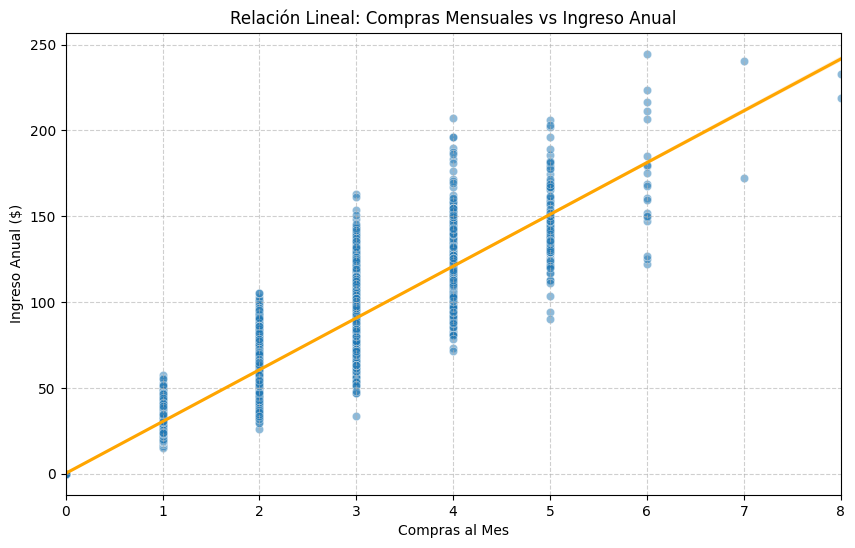

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.5)
sns.regplot(data=df, x='compras_mes', y='ingreso_anual',
    scatter=False, color='orange')

plt.title('Relación Lineal: Compras Mensuales vs Ingreso Anual')
plt.xlabel('Compras al Mes')
plt.ylabel('Ingreso Anual ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Scatterplot para pares clave

<Figure size 1200x1000 with 0 Axes>

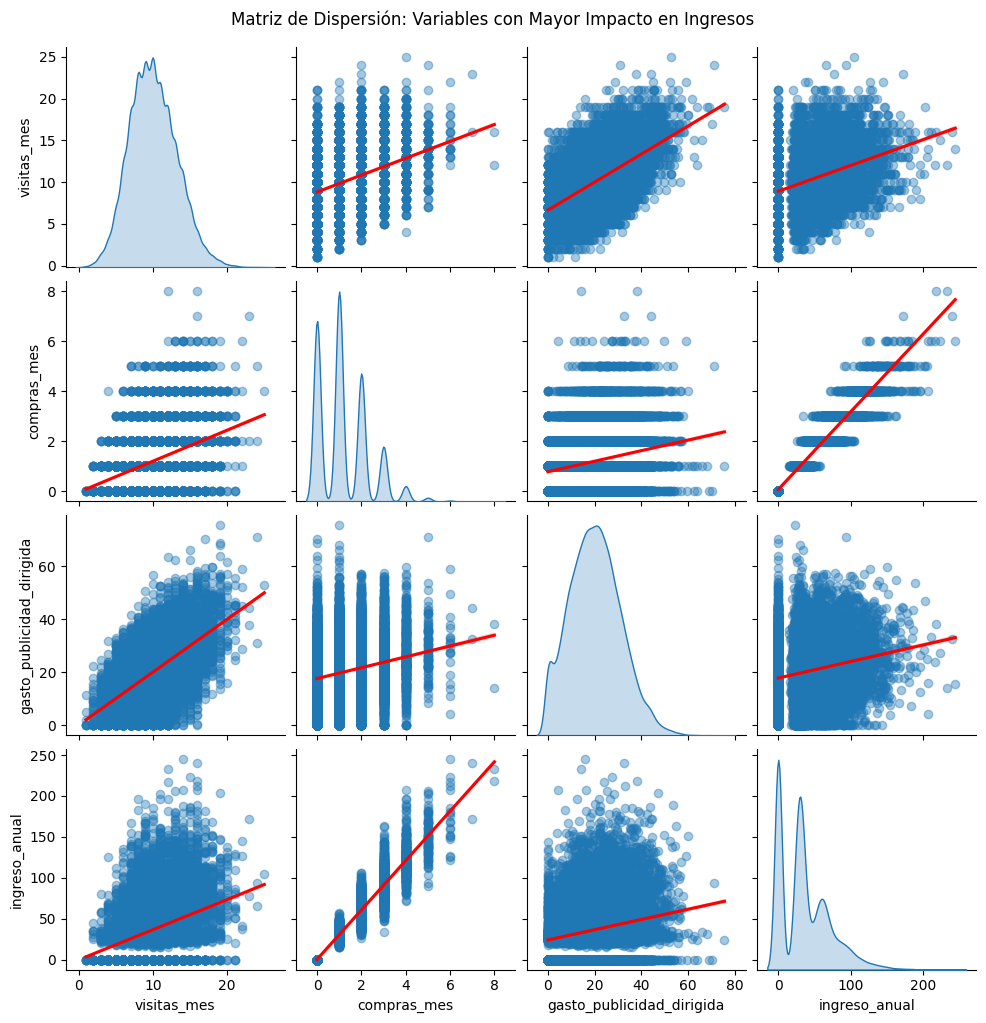

In [54]:
# Visualizar pares de variables con relaciones moderadas o fuertes
vars_interes=['visitas_mes','compras_mes','gasto_publicidad_dirigida','ingreso_anual']

plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(
    df[vars_interes], 
    kind='reg', 
    diag_kind='kde', 
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.4}}
)

pair_plot.fig.suptitle("Matriz de Dispersión: Variables con Mayor Impacto en Ingresos", y=1.02)
plt.show()



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   

Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

**var1 vs var2** Variable Ingreso_anual vs visitas_mes
- Dirección positiva media
- La linea esta inclinada hacia abajo tiene una relación moderada
- Dispersión media
- Presencia de reducidos outliers

**var1 vs var3** Variable Ingreso_anual vs compras_mes
- Dirección Positiva
- La linea esta empinada es una relacción fuerte
- Dispersión baja
- Escasos outliers

**var1 vs var4** Variable Ingreso_anual vs gasto_publicidad_dirigida
- Dirección negativa 
- la línea es más plana y los puntos están muy dispersos
- Dispersión alta
- Presencia de reducidos outliers

Para poder indetificar puntualmente la colinealidad es importante usar Pearson y Spearman, para ver patrones no lineales o outliers


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [55]:
# Calcular correlación entre variables relevantes
columnas_numericas = [
    'edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
    'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual'
]

pearson_vals = df[columnas_numericas].corr(method='pearson')['ingreso_anual']


print("Correlación de las variables con el Ingreso Anual con Pearson:")

print(pearson_vals)


Correlación de las variables con el Ingreso Anual con Pearson:
edad                         0.017496
nivel_ingreso                0.017446
visitas_mes                  0.337147
compras_mes                  0.967149
gasto_publicidad_dirigida    0.197483
satisfaccion                 0.056171
ingreso_anual                1.000000
Name: ingreso_anual, dtype: float64


In [56]:
# Calcular correlación entre variables relevantes

spearman_vals = df[columnas_numericas].corr(method='spearman')['ingreso_anual']

print("Correlación de las variables con el Ingreso Anual con Spearman:")

print(spearman_vals)


Correlación de las variables con el Ingreso Anual con Spearman:
edad                         0.016097
nivel_ingreso                0.025017
visitas_mes                  0.320954
compras_mes                  0.967482
gasto_publicidad_dirigida    0.184999
satisfaccion                 0.060834
ingreso_anual                1.000000
Name: ingreso_anual, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.

Observaciones de correlación

**var1 vs var2**
- Ingreso_anual y compras_mes: Existe una correlación positiva muy fuerte (0.96), lo que indica que un mayor ingreso anual está asociado con compras mensuales significativamente más altas.

Los valores cercanos a 0 esa variable no influye en el ingreso_anual, sin importar el método que uses.
Comparando con los resultado de spearman, solo una una diferencia de 0.01 con visitas_mes, de ahí el análisis es el mismo 

**var2 vs var3**
- Ingreso_anual y visitas_mes: Se observa una correlación positiva moderada (0.33), sugiriendo que a mayor ingreso, hay una ligera tendencia a un número superior de visitas mensuales.
- Ingreso_anual y gasto_publicidad_dirigida: La correlación es positiva, pero débil (0.18), lo que implica que el impacto del ingreso anual sobre el gasto en publicidad dirigida es mínimo.


Las variables con valores cercanos a cero no ejerce influencia sobre el ingreso_anual, independientemente del método de análisis utilizado.

Al comparar con los resultados de Spearman, solo se observa una diferencia de 0.01 en la variable visitas_mes; el resto del análisis permanece idéntico.


### Punto-biserial

In [57]:
# Calcular correlación entre variables relevantes
# 1. Definir la variable numérica objetivo
metrica_foco = 'ingreso_anual'

# 2. Definir las variables binarias a analizar
vars_binarias = ['miembro_premium', 'abandono']

print(f"Análisis de Correlación Punto-Biserial con {metrica_foco}:\n")

for col in vars_binarias:
       
    # Calcular correlación punto-biserial
    coef, p_value = pointbiserialr(df[col], df[metrica_foco])
    
    print(f"Variable: {col}")
    print(f"  - Coeficiente: {coef:.4f}")
    print(f"  - P-value: {p_value:.4e}") # Notación científica para valores muy pequeños
    
    # Interpretación rápida
    if p_value < 0.05:
        print("  - Resultado: Estadísticamente significativo.")
    else:
        print("  - Resultado: No se observa una relación significativa.")
    print("-" * 30)


Análisis de Correlación Punto-Biserial con ingreso_anual:

Variable: miembro_premium
  - Coeficiente: 0.0931
  - P-value: 3.0943e-30
  - Resultado: Estadísticamente significativo.
------------------------------
Variable: abandono
  - Coeficiente: -0.0028
  - P-value: 7.2947e-01
  - Resultado: No se observa una relación significativa.
------------------------------


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- El coeficiente de 0.09, que relaciona la variable "ingreso_anual" con "miembro_premium", es positivo pero débil, lo que indica que la diferencia entre los ingresos de ambos grupos es pequeña. En términos sencillos: si bien los usuarios suscritos tienden a ganar un poco más, esta diferencia no es significativa.


**var2 vs var3**
- La relación entre el ingreso_anual y el abandono resultó en un coeficiente de 0, lo que indica la ausencia de una correlación lineal entre ambas variables.
Se esperaba un valor negativo, ya que un menor ingreso anual se asociaría lógicamente con la decisión de un cliente de abandonar la plataforma.

Ambos índices analizados sugieren que la pertenencia o no a la categoría miembro_premium no ejerce un efecto distinguible en el ingreso 


### V de Cramér

In [58]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency


In [59]:
# Aplicar V de Cramér en variables relevantes
vars_cat = ['region', 'tipo_dispositivo']
def cramer_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    return v
print("Asociación entre variables categóricas (V de Cramér):")
print(f"- Región vs Tipo de Dispositivo: {cramer_v(df, 'region', 'tipo_dispositivo'):.4f}")


Asociación entre variables categóricas (V de Cramér):
- Región vs Tipo de Dispositivo: 0.0124


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

Asociación de las variables región y tipo de dispositivo generó un coeficiente de 0.01, esta resulta muy débil, por lo tanto la región no influye en qué dispositivo usan.




## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — El motor principal del ingreso anual
**Evidencia visual:** Scatter Plot de compras_mes vs. ingreso_anual   
**Evidencia numérica:** Correlación de Pearson de 0.97 (Muy fuerte).

**Interpretación**  Existe una relación lineal casi perfecta y positiva entre la cantidad de compras mensuales y el ingreso anual generado por el cliente. A mayor frecuencia de compra, el valor del cliente para la empresa escala de forma predecible.

**No podemos afirmar**Que obligar al cliente a comprar más veces aumentará su ingreso anual automáticamente (causalidad), ya que el ingreso anual es, por definición, el resultado de esas compras.  

**Implicación de negocio** Las estrategias de fidelización y retención (como cupones para una segunda compra en el mes) son el camino más directo para incrementar el valor de vida del cliente











### Hallazgo 2 — Eficiencia de la inversión publicitaria

**Evidencia visual:** Heatmap global y Pairplot.

**Evidencia numérica:** Correlación de Pearson de 0.58 entre gasto_publicidad_dirigida y visitas_mes.

**Interpretación**  El gasto en publicidad dirigida muestra una asociación moderada-fuerte con el flujo de visitas a la plataforma. Esto sugiere que las campañas están logrando captar la atención del usuario.

**No podemos afirmar** Que cada peso invertido en publicidad se convierta directamente en una compra, ya que la relación entre publicidad e ingreso_anual es menor (0.20) que la relación con las visitas. 


**Implicación de negocio**La publicidad es excelente para generar tráfico (visitas), pero hay una "fuga" entre la visita y la compra. El equipo de Producto debería optimizar la experiencia de usuario (UX) para que ese tráfico publicitario convierta mejor en ventas reales.  


### Hallazgo 3 — Independencia de los factores demográficos

**Evidencia visual:** Heatmap global (bloque de celdas gris claro en la esquina superior izquierda).

**Evidencia numérica:** Correlaciones de edad y nivel_ingreso con ingreso_anual cercanas a 0.02 y 0.00.

**Interpretación**  Existe una falta de asociación lineal entre el perfil demográfico del cliente (edad e ingresos estimados) y su comportamiento de gasto real en la plataforma. Esto indica que el valor del cliente no está determinado por quién es, sino por cómo interactúa con la marca.

**No podemos afirmar** Que los clientes jóvenes o de mayores ingresos no sean valiosos, sino que sus perfiles demográficos por sí solos no predicen cuánto gastarán en NovaRetail+. 

**Implicación de negocio**El equipo de marketing debe priorizar la segmentación conductual (basada en clics, visitas y compras previas) por encima de la segmentación demográfica tradicional. Es más efectivo hacer publicidad basada en "lo que el cliente hace" que en "qué edad tiene". 

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Este es un análisis correlacional; no podemos asegurar que aumentar las visitas causará automáticamente un aumento en ingresos, solo que ambas variables se mueven juntas.
- Los datos se limitan al año 2024. No se consideran factores externos como inflación o cambios en la competencia.

### **Próximos pasos** 

Probar segmentación adicional

- [opcion 1]  Análisis de Ticket Promedio: Investigar por qué existe tanta dispersión en el ingreso para clientes con el mismo número de compras (analizar el valor de los productos elegidos).

- [opcion 2] A/B Testing: Realizar experimentos controlados en el flujo de "Visitas a Compras" para intentar convertir ese tráfico publicitario en ventas efectivas.
